### PART 1: Load and Inspect

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#make chart looks nice
sns.set_theme(style='whitegrid', palette='muted')

In [3]:
import pandas as pd
Housing_path ='/kaggle/input/datasets/kryusufkaya/housing/Housing.csv'
Housing_df = pd.read_csv(Housing_path)
Housing_df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# The column
Housing_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [5]:
Housing_df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus']

In [6]:
# the size of the dataset
Housing_df.shape

(545, 13)

In [7]:
# the data types for every column
Housing_df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [8]:
# Summarry statistics
Housing_df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [9]:
# The unique counts for categorical column
unique_counts =Housing_df.select_dtypes(include=['object', 'category']).nunique()
unique_counts

mainroad            2
guestroom           2
basement            2
hotwaterheating     2
airconditioning     2
prefarea            2
furnishingstatus    3
dtype: int64

## PART 2: Data Cleaning

In [10]:
# Checking for missing value
Housing_df.isnull()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,False,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False,False
542,False,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
# Cal. the misssing counts
missing_counts = Housing_df.isnull().sum()
missing_counts

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [12]:
# cal. the percentage 
missing_percent = (Housing_df.isnull().mean() * 100).round(2)
missing_percent

price               0.0
area                0.0
bedrooms            0.0
bathrooms           0.0
stories             0.0
mainroad            0.0
guestroom           0.0
basement            0.0
hotwaterheating     0.0
airconditioning     0.0
parking             0.0
prefarea            0.0
furnishingstatus    0.0
dtype: float64

In [13]:
# missing summary
missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)':missing_percent})
missing_summary

,Missing Values,Percentage (%)
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [14]:
# Checking for duplicate 
Housing_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Length: 545, dtype: bool

In [15]:
# Duplicate Summary
total_rows = len(Housing_df)
dup_count = Housing_df.duplicated().sum()

print(f"Data Check Summary: Found {dup_count} duplicate rows out of {total_rows} total records.")


Data Check Summary: Found 0 duplicate rows out of 545 total records.


## Outlier in Price and Area Using the IQR Method

### Outlier in Price

In [16]:
## Outlier in Price
# Turkey's
# Q1 - 1.5 * IQR- Lower limit
# Q3 + 1.5 * IQR- Upper limit

In [17]:
Q1= Housing_df['price'].quantile(.25)
Q3= Housing_df['price'].quantile(.75)
IQR= Q3-Q1

In [18]:
#IQR
IQR

np.float64(2310000.0)

In [19]:
lower_limits=Q1-1.5 * IQR
upper_limits=Q3+1.5 * IQR

In [20]:
# Lower Limits
lower_limits

np.float64(-35000.0)

In [21]:
# Upper Limits
upper_limits

np.float64(9205000.0)

In [22]:
# Outlier Upper
outlier_upper=(Housing_df['price']>upper_limits)

In [23]:
outlier_upper

0       True
1       True
2       True
3       True
4       True
       ...  
540    False
541    False
542    False
543    False
544    False
Name: price, Length: 545, dtype: bool

In [24]:
# Outlier Found
len(Housing_df['price'])-len(Housing_df['price'][outlier_upper])

530

### Outliers in Area

In [25]:
# Turkey's
# Q1 - 1.5 * IQR- Lower limit
# Q3 + 1.5 * IQR- Upper limi

In [26]:
Q1= Housing_df['area'].quantile(.25)
Q3= Housing_df['area'].quantile(.75)
IQR= Q3-Q1

In [27]:
# the IQR
IQR

np.float64(2760.0)

In [28]:
lower_limits=Q1-1.5 * IQR
upper_limits=Q3+1.5 * IQR

In [29]:
# Lower Limits
lower_limits

np.float64(-540.0)

In [30]:
#Upper Limit
upper_limits

np.float64(10500.0)

In [31]:
outlier_upper=(Housing_df['area']>upper_limits)

In [32]:
#outlier_upper
outlier_upper

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Name: area, Length: 545, dtype: bool

In [33]:
#outlier found
len(Housing_df['area'])-len(Housing_df['area'][outlier_upper])

533

### Unexpected Entities

In [34]:
# Expected values
expected_values = {
    'mainroad': ['yes', 'no'],
    'guestroom': ['yes', 'no'],
    'basement': ['yes', 'no'],
    'hotwaterheating': ['yes', 'no'],
    'airconditioning': ['yes', 'no'],
    'prefarea': ['yes', 'no'],
    'furnishingstatus': ['furnished', 'semi-furnished', 'unfurnished']
}

# checking for unexpected values
for col, expected in expected_values.items():
    actual = Housing_df[col].unique().tolist()
    unexpected = [v for v in actual if v not in expected]
    if unexpected:
        print(f"{col}: UNEXPECTED VALUES -> {unexpected}")
    else:
        print(f"\n{col}: OK — all values as expected ({actual})")


mainroad: OK — all values as expected (['yes', 'no'])

guestroom: OK — all values as expected (['no', 'yes'])

basement: OK — all values as expected (['no', 'yes'])

hotwaterheating: OK — all values as expected (['no', 'yes'])

airconditioning: OK — all values as expected (['yes', 'no'])

prefarea: OK — all values as expected (['yes', 'no'])

furnishingstatus: OK — all values as expected (['furnished', 'semi-furnished', 'unfurnished'])


### Data(Housing Dataset) Summary

Based on the research carried out so far,here's my summary:

No missing values or duplicate rows were found in the dataset. Hence, no records needed to be removed. The IQR method identified [530] outliers in price and [533] outliers in area, which represent genuine high-value properties; these were not removed, as doing so could hide real patterns within that segment of the market. All categorical columns contain only their expected values, with no unexpected entries found. In conclusion, the Housing dataset is clean and ready for analysis.

## PART 3: Analysis Questions

In [35]:
# checking for the average, median, and mode of the housing price
# checking the housing price type
Housing_df['price'].dtypes

dtype('int64')

In [36]:
# for the average of the housing price
average_price= Housing_df['price'].mean()
average_price

np.float64(4766729.247706422)

In [37]:
# For the median of the housing price
median_price= Housing_df['price'].median()
median_price

4340000.0

In [38]:
#Mode for the housing price
mode_price= Housing_df['price'].mode()
mode_price

0    3500000
1    4200000
Name: price, dtype: int64

In [39]:
### Correlation Between area and price
# Cal. correlation
correlation = Housing_df['area'].corr(Housing_df['price'])
correlation

np.float64(0.5359973457780797)

In [40]:
### Most Expensive House
#top 5 most espensive housing
top5 = Housing_df.sort_values('price', ascending=False).head(5)
top5

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [41]:
### Observation of the top 5 most expensive houses
print('Obervation for the top 5 most expensive house')
print('\nThe top 5 most expensive houses share several common features: ')
print('Location: All are located on the mainroad,')
print('majority of them have 4bedroom buildings,and are furnished.')
print('All furnished has airconditioning, but none has hotwaterheater.')

Obervation for the top 5 most expensive house

The top 5 most expensive houses share several common features: 
Location: All are located on the mainroad,
majority of them have 4bedroom buildings,and are furnished.
All furnished has airconditioning, but none has hotwaterheater.


#### Featuring Impact on pricing

In [42]:
### Comparing the prices 
# Total average price

total_average= Housing_df['price'].mean()
total_average

np.float64(4766729.247706422)

In [43]:
# Price Comparison
price_comparison = Housing_df.groupby('mainroad')['price'].mean()
price_comparison


mainroad
no     3.398905e+06
yes    4.991777e+06
Name: price, dtype: float64

In [44]:
# checking if airconditioning affect house price
air_price = Housing_df.groupby('airconditioning')['price'].mean()
air_price

airconditioning
no     4.191940e+06
yes    6.013221e+06
Name: price, dtype: float64

In [45]:
# checking if furnishingstatus affect house price
furnishingstatus_price = Housing_df.groupby('furnishingstatus')['price'].mean()
ranking= furnishingstatus_price.sort_values(ascending=False)
ranking

furnishingstatus
furnished         5.495696e+06
semi-furnished    4.907524e+06
unfurnished       4.013831e+06
Name: price, dtype: float64

In [46]:
# Interpretation
print('Furnished houses have the highest average price,')
print('and the unfurnished houses having the least price.')
print('Henec,price rises with finished leve.')

Furnished houses have the highest average price,
and the unfurnished houses having the least price.
Henec,price rises with finished leve.


In [47]:
#checking if prefareas affect house price
prefarea_price = Housing_df.groupby('prefarea')['price'].mean()
prefarea_price

prefarea
no     4.425299e+06
yes    5.879046e+06
Name: price, dtype: float64

In [48]:
# checking if prefarea commands a price premium
premium = prefarea_price['yes'] - prefarea_price['no']
premium

np.float64(1453746.9261465827)

### Distribution & Patterns

In [49]:
# The most common number of beds
most_common_bedrooms = Housing_df['bedrooms'].mode()[0]
most_common_bedrooms

np.int64(3)

In [50]:
# Percentage of 3 bedrooms houses
percentage=(Housing_df['bedrooms']== 3).mean() * 100
percentage

np.float64(55.04587155963303)

In [51]:
# Houses with both basement AND air conditioning
# BA= both basement AND air conditioning
BA = Housing_df[(Housing_df['basement'] == 'yes') & (Housing_df['airconditioning'] == 'yes')]

BA_count = len(BA)
BA_count

66

In [52]:
# The average price
average_price = BA['price'].mean()
average_price

np.float64(6081196.96969697)

In [53]:
#Relationship between stories and price
# Average price by number of stories
stories_price = Housing_df.groupby('stories')['price'].mean()
stories_price

stories
1    4.170659e+06
2    4.764074e+06
3    5.685436e+06
4    7.208450e+06
Name: price, dtype: float64

In [54]:
# Describing the trends
#Checking the correlation
correlation = Housing_df['stories'].corr(Housing_df['price'])
correlation


np.float64(0.42071236618861624)

## PART4: VISUALISATIONS

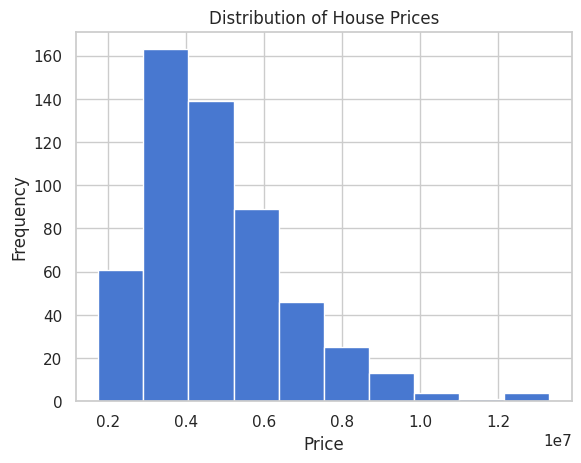

In [55]:
### Histogram Chart
# Distribution of price

Housing_df['price'].plot(kind='hist', title='Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

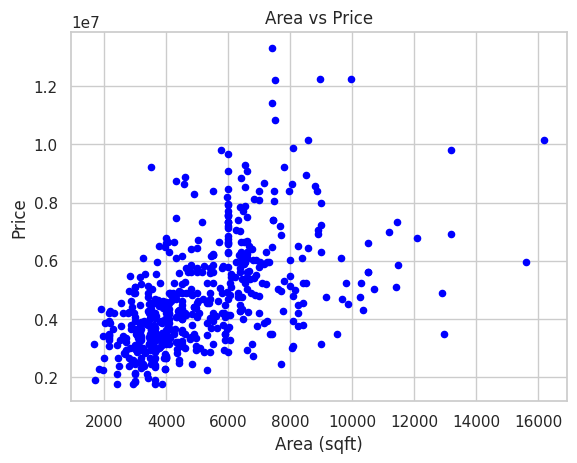

In [56]:
### Scatter Plot
# Area vs Price, coloured by furnishingstatus

Housing_df.plot(kind='scatter', x='area', color='blue', y='price', title='Area vs Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price')
plt.show()

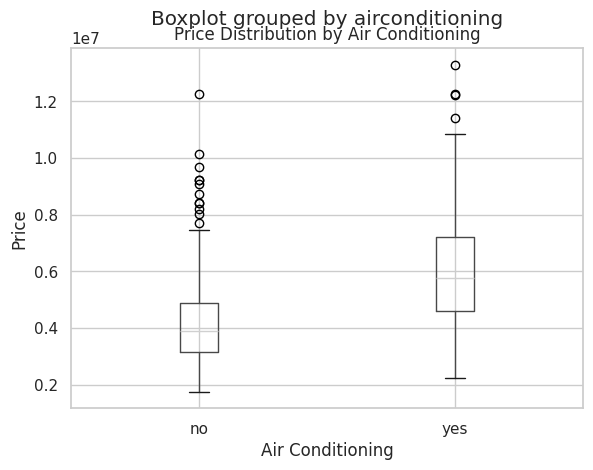

In [57]:
### Box Plot
# price grouped by airconditioning (yes/no)

Housing_df.boxplot(column='price', by='airconditioning')
plt.title('Price Distribution by Air Conditioning')
plt.xlabel('Air Conditioning')
plt.ylabel('Price')
plt.show()

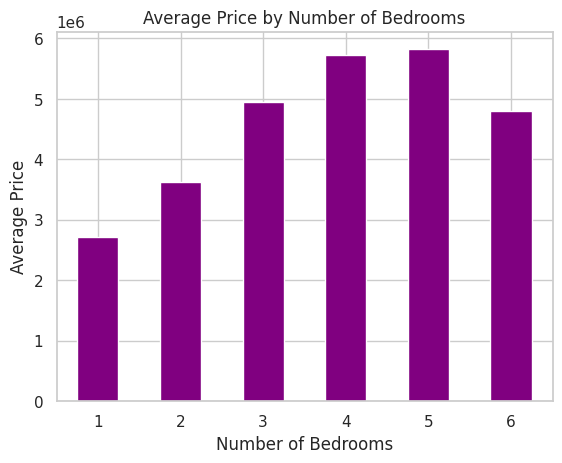

In [58]:
Housing_df.groupby('bedrooms')['price'].mean().plot(kind='bar', color='purple', title='Average Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()

In [61]:
# Heatmap or Correlation

Housing_df["mainroad"] = Housing_df["mainroad"].map({"yes": 1, "no": 0})
Housing_df["guestroom"] = Housing_df["guestroom"].map({"yes": 1, "no": 0})
Housing_df["basement"] = Housing_df["basement"].map({"yes": 1, "no": 0})
Housing_df["hotwaterheating"] = Housing_df["hotwaterheating"].map({"yes": 1, "no": 0})
Housing_df["airconditioning"] = Housing_df["airconditioning"].map({"yes": 1, "no": 0})
Housing_df["prefarea"] = Housing_df["prefarea"].map({"yes": 1, "no": 0})

corr = Housing_df[["price", "area", "bedrooms", "bathrooms", "stories", "parking",
           "mainroad", "guestroom", "basement", "hotwaterheating",
           "airconditioning", "prefarea"]].corr()

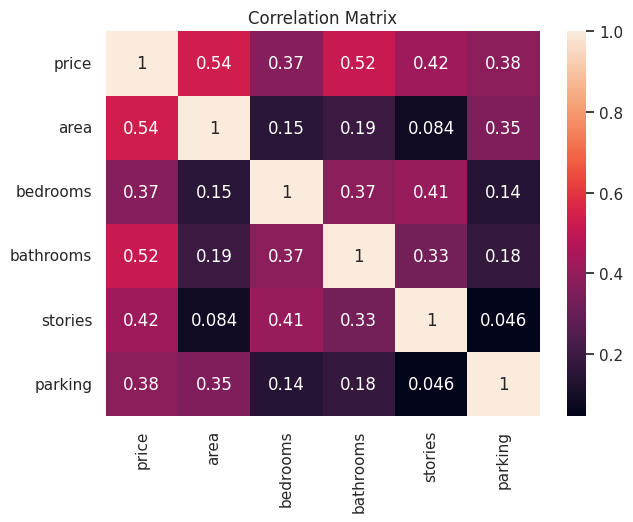

In [62]:
corr = Housing_df[["price", "area", "bedrooms", "bathrooms", "stories", "parking"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True,)
plt.title("Correlation Matrix")
plt.show()